<div style="text-align: right;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5e/HdM_Logo.svg/100px-HdM_Logo.svg.png"
       alt="HdM Logo"
       width="120">
</div>

###  NYC und weitere Städte: Datenbereinigung, erste einfache EDA und lineare Regression

---

Annette Kufner

---


In diesem Notebook werden erste Versuche unternommen, um den Airbnb-Datensatz von New York City zu bereinigen, eine einfache explorative Datenanalyse (EDA) durchzuführen und eine lineare Regression auszuprobieren, um mögliche Zusammenhänge zwischen verschiedenen Merkmalen zu untersuchen. Wichtige Erkenntnisse und Ideen wurden dann weiterentwickelt und ins Notebook *draft analysis* übernommen. Zu einem späteren Zeitpunkt wurden dann weitere Datensätze amerikanischer Städte eingelesen, um zu sehen, ob diese Städte ähnlich verarbeitet werden können und ob sich Muster erkennen lassen.

Erkenntnis: Leider fehlen in den Datensätzen der Städte oftmals die Werte in der Spalte 'price' oder die Spalte 'neighbourhood_group_cleansed' komplett. Damit kann weder die Zielvariable noch die wichtigste kategoriale Variable des OLS-Modells verwendet werden und die lineare Regression zu NYC in *draft analysis* nicht 1:1 auf andere Städte übertragen werden.

Dennoch sind insbesondere im Abschnitt MODEL die wichtigsten Schritte zum Vorgehensweise bei der linearen Regression.

Datensatz von https://insideairbnb.com/get-the-data/

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display

In [149]:
import sys
import os

# Definiert den relativen Pfad zum 'src' Ordner
# .. = Ein Ordner hoch zum Projekt-Root
# /src = Dann in den Ordner src
src_path = os.path.join(os.getcwd(), '..', 'src')

# Fügt diesen Pfad dem Python-Suchpfad hinzu
if src_path not in sys.path:
    sys.path.append(src_path)

print(f"✅ src-Ordner temporär zum Suchpfad hinzugefügt: {src_path}")

✅ src-Ordner temporär zum Suchpfad hinzugefügt: c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\notebooks\..\src


In [150]:
df = pd.read_csv("../data/processed/airbnb_NYC_model_data.csv")

In [151]:
df.head()

,id,neighbourhood_group_cleansed,room_type,instant_bookable,accommodates,bathrooms,bedrooms,beds,host_total_listings_count,distance_to_center,price,ln_price
0,40824219,Queens,Private room,False,1,1.0,1.0,1.0,3.0,5.846824,66.0,4.204693
1,40839416,Manhattan,Private room,False,1,2.0,1.0,1.0,16.0,4.068795,76.0,4.343805
2,40843980,Queens,Entire home/apt,False,6,1.0,2.0,3.0,2.0,14.496832,97.0,4.584967
3,40824301,Brooklyn,Private room,False,1,1.0,2.0,1.0,1.0,6.134544,60.0,4.110874
4,40825740,Brooklyn,Entire home/apt,False,6,4.0,3.0,3.0,9.0,10.045623,425.0,6.054439


In [152]:
df[['price', 'neighbourhood_group_cleansed']].isnull().sum()

price                           0
neighbourhood_group_cleansed    0
dtype: int64

In [154]:
df.describe()

,id,accommodates,bathrooms,bedrooms,beds,host_total_listings_count,distance_to_center,price,ln_price
count,1.980800e+04,19808.000000,19801.000000,19722.000000,19768.000000,18907.000000,19808.000000,19808.000000,19808.000000
mean,6.365630e+17,2.693811,1.153528,1.307778,1.569000,153.211086,8.168982,179.059673,4.965717
std,5.520376e+17,1.738030,0.461184,0.912971,1.053193,656.579760,5.558606,122.497186,0.688534
min,2.595000e+03,1.000000,0.000000,0.000000,0.000000,1.000000,0.013191,10.000000,2.397895
25%,4.226178e+07,2.000000,1.000000,1.000000,1.000000,2.000000,3.758194,85.000000,4.454347
50%,7.499948e+17,2.000000,1.000000,1.000000,1.000000,5.000000,7.745291,145.000000,4.983607
75%,1.118677e+18,4.000000,1.000000,2.000000,2.000000,21.000000,11.228109,240.000000,5.484797
max,1.521847e+18,16.000000,10.500000,9.000000,16.000000,6815.000000,35.920435,564.000000,6.336826


In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19808 entries, 0 to 19807
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            19808 non-null  int64  
 1   neighbourhood_group_cleansed  19808 non-null  object 
 2   room_type                     19808 non-null  object 
 3   instant_bookable              19808 non-null  bool   
 4   accommodates                  19808 non-null  int64  
 5   bathrooms                     19801 non-null  float64
 6   bedrooms                      19722 non-null  float64
 7   beds                          19768 non-null  float64
 8   host_total_listings_count     18907 non-null  float64
 9   distance_to_center            19808 non-null  float64
 10  price                         19808 non-null  float64
 11  ln_price                      19808 non-null  float64
dtypes: bool(1), float64(7), int64(2), object(2)
memory usage: 1.

## Feature Engineering: Distance to center als neue Spalte

Ausgangspunkt: latitude, longitude   
Ziel: Abstand zum Times Square (als Center von NYC messen)

Hinweis: Diese Überlegungen wurden ausgelagert und werden bei der Erstellung der VIEW aus der Datenbank umgesetzt (siehe Notebook 01_NYC_Datenbereinigung_DB.ipynb)

#### One Hot Encoding: Instant_bookable

Code und Erkenntnisse dieses Abschitts wurden ausgelagert in andere Notebooks bzw. wird im finalen Model der linearen Regression bisher NICHT umgesetzt. 'Instant_bookable' ist aber definitiv ein potentieller Preistreiber!

### EDA

siehe: https://www.youtube.com/watch?v=O2Cw82YR5Bo

#### Zielvariable Price

a) Boxplots

<Axes: xlabel='price'>

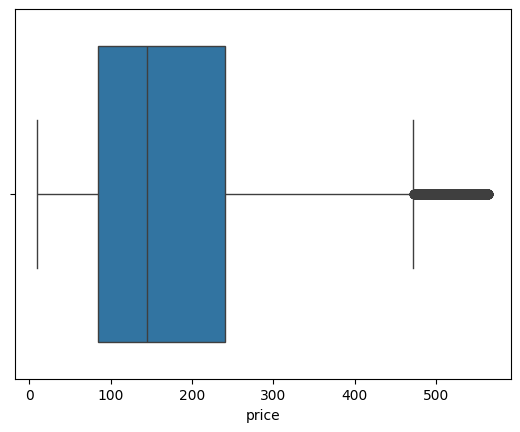

In [156]:
sns.boxplot(x='price', data= df)

Gemini: "Wenn Sie sich nicht auf einen festen Wert ($1000) festlegen möchten, können Sie auch das 99. Perzentil Ihres eigenen Datensatzes verwenden. Das schließt die extremsten 1% der Ausreißer aus und zeigt 99% der Daten."

99. Perzentil liegt bei: $534.00


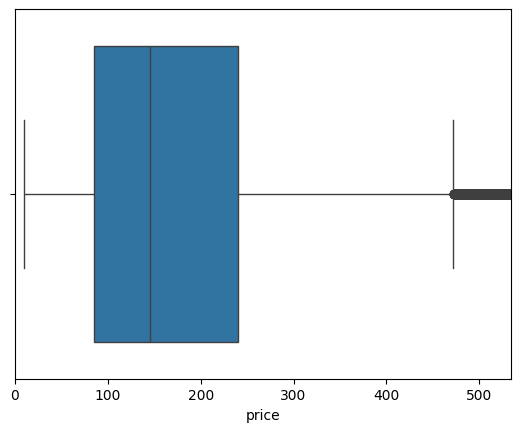

In [158]:
# Berechnung des 99. Perzentils
limit_99 = df['price'].quantile(0.99)
print(f"99. Perzentil liegt bei: ${limit_99:.2f}") 

# Plot-Befehl mit dem berechneten Limit:
sns.boxplot(x='price', data=df)
plt.xlim(0, limit_99) 
plt.show()

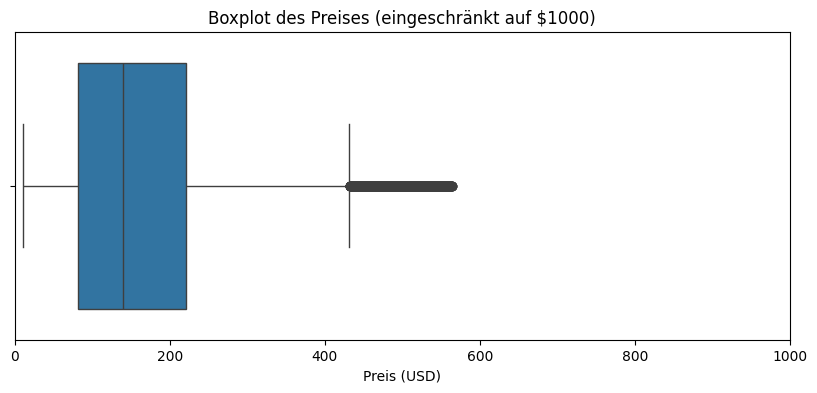

In [159]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# 1. Erstellen des Boxplots
sns.boxplot(x='price', data=df_clean)

# 2. EINSCHRÄNKUNG DER X-ACHSE (von 0 bis 1000 USD)
plt.xlim(0, 1000) 

plt.title('Boxplot des Preises (eingeschränkt auf $1000)')
plt.xlabel('Preis (USD)')
plt.show()

#### Scatterplots

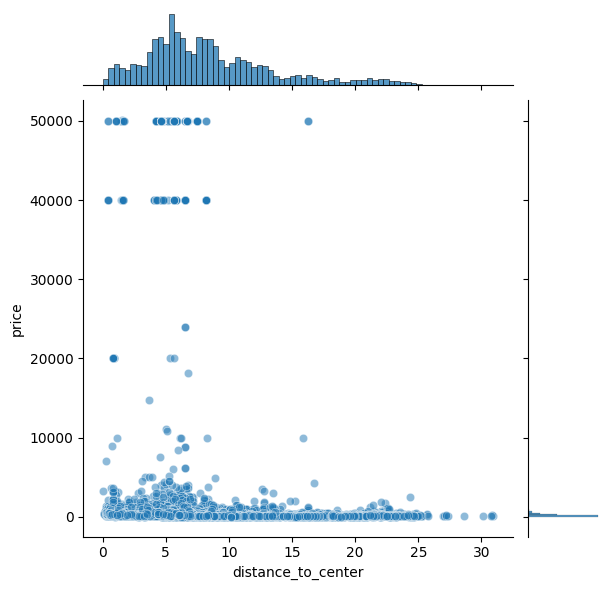

In [160]:
sns.jointplot(x='distance_to_center', y='price', data=df1, alpha=0.5)

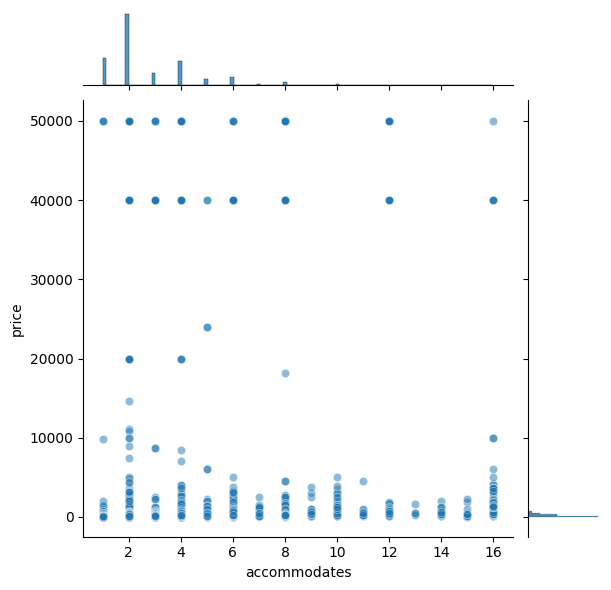

In [161]:
sns.jointplot(x='accommodates', y='price', data=df1, alpha=0.5)

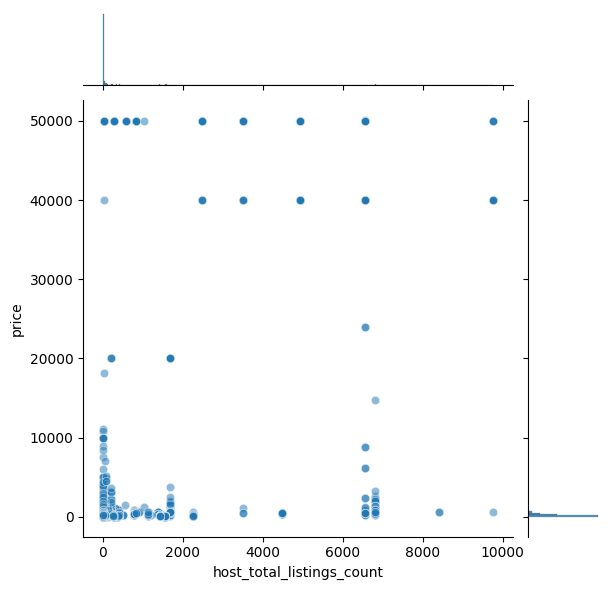

In [162]:
sns.jointplot(x='host_total_listings_count', y='price', data=df1, alpha=0.5)

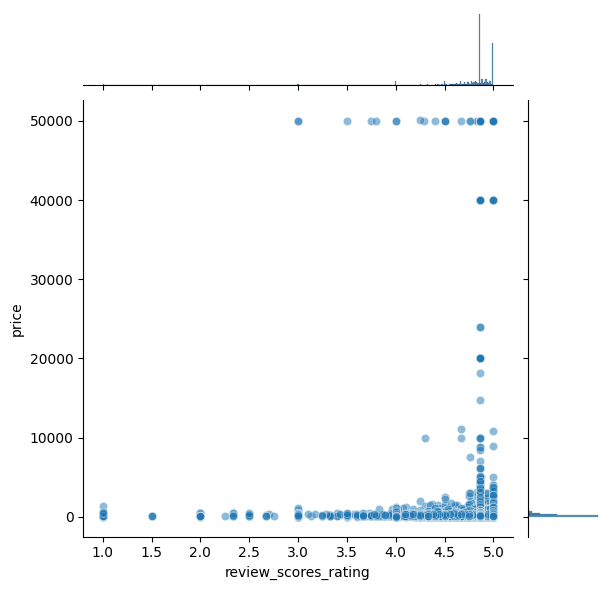

In [163]:

sns.jointplot(x='review_scores_rating', y='price', data=df1, alpha=0.5)

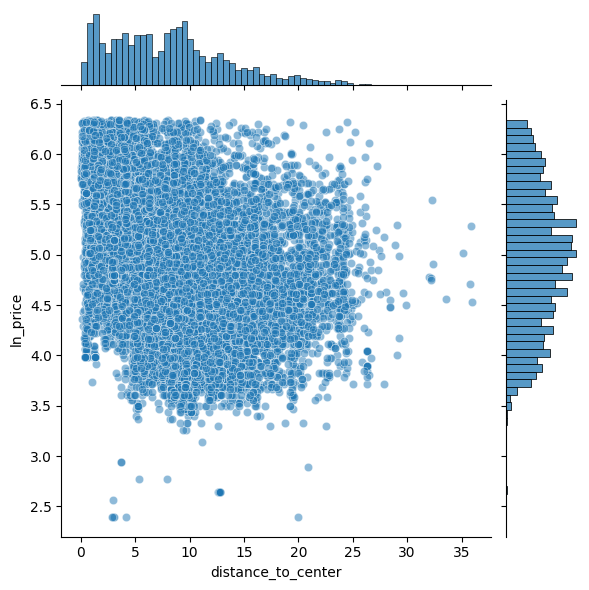

In [166]:
sns.jointplot(x='distance_to_center', y='ln_price', data=df, alpha=0.5)

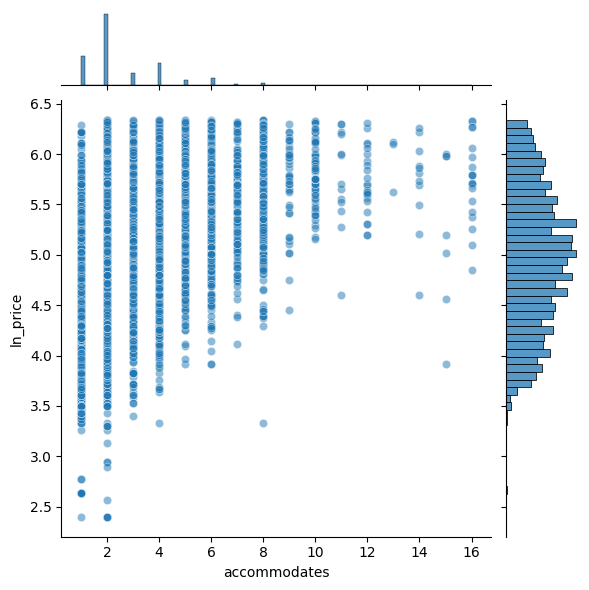

In [167]:
sns.jointplot(x='accommodates', y='ln_price', data=df, alpha=0.5)

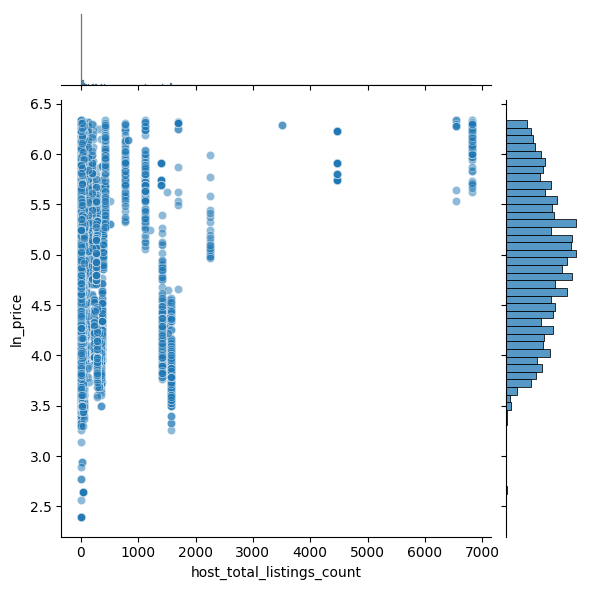

In [168]:
sns.jointplot(x='host_total_listings_count', y='ln_price', data=df, alpha=0.5)

ValueError: Could not interpret value `review_scores_rating` for `x`. An entry with this name does not appear in `data`.

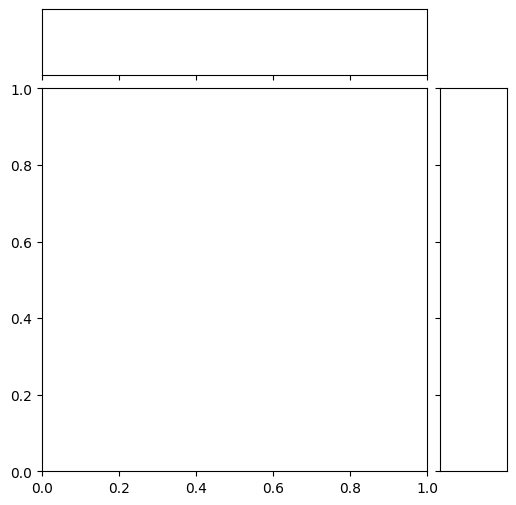

In [169]:
sns.jointplot(x='review_scores_rating', y='ln_price', data=df, alpha=0.5)

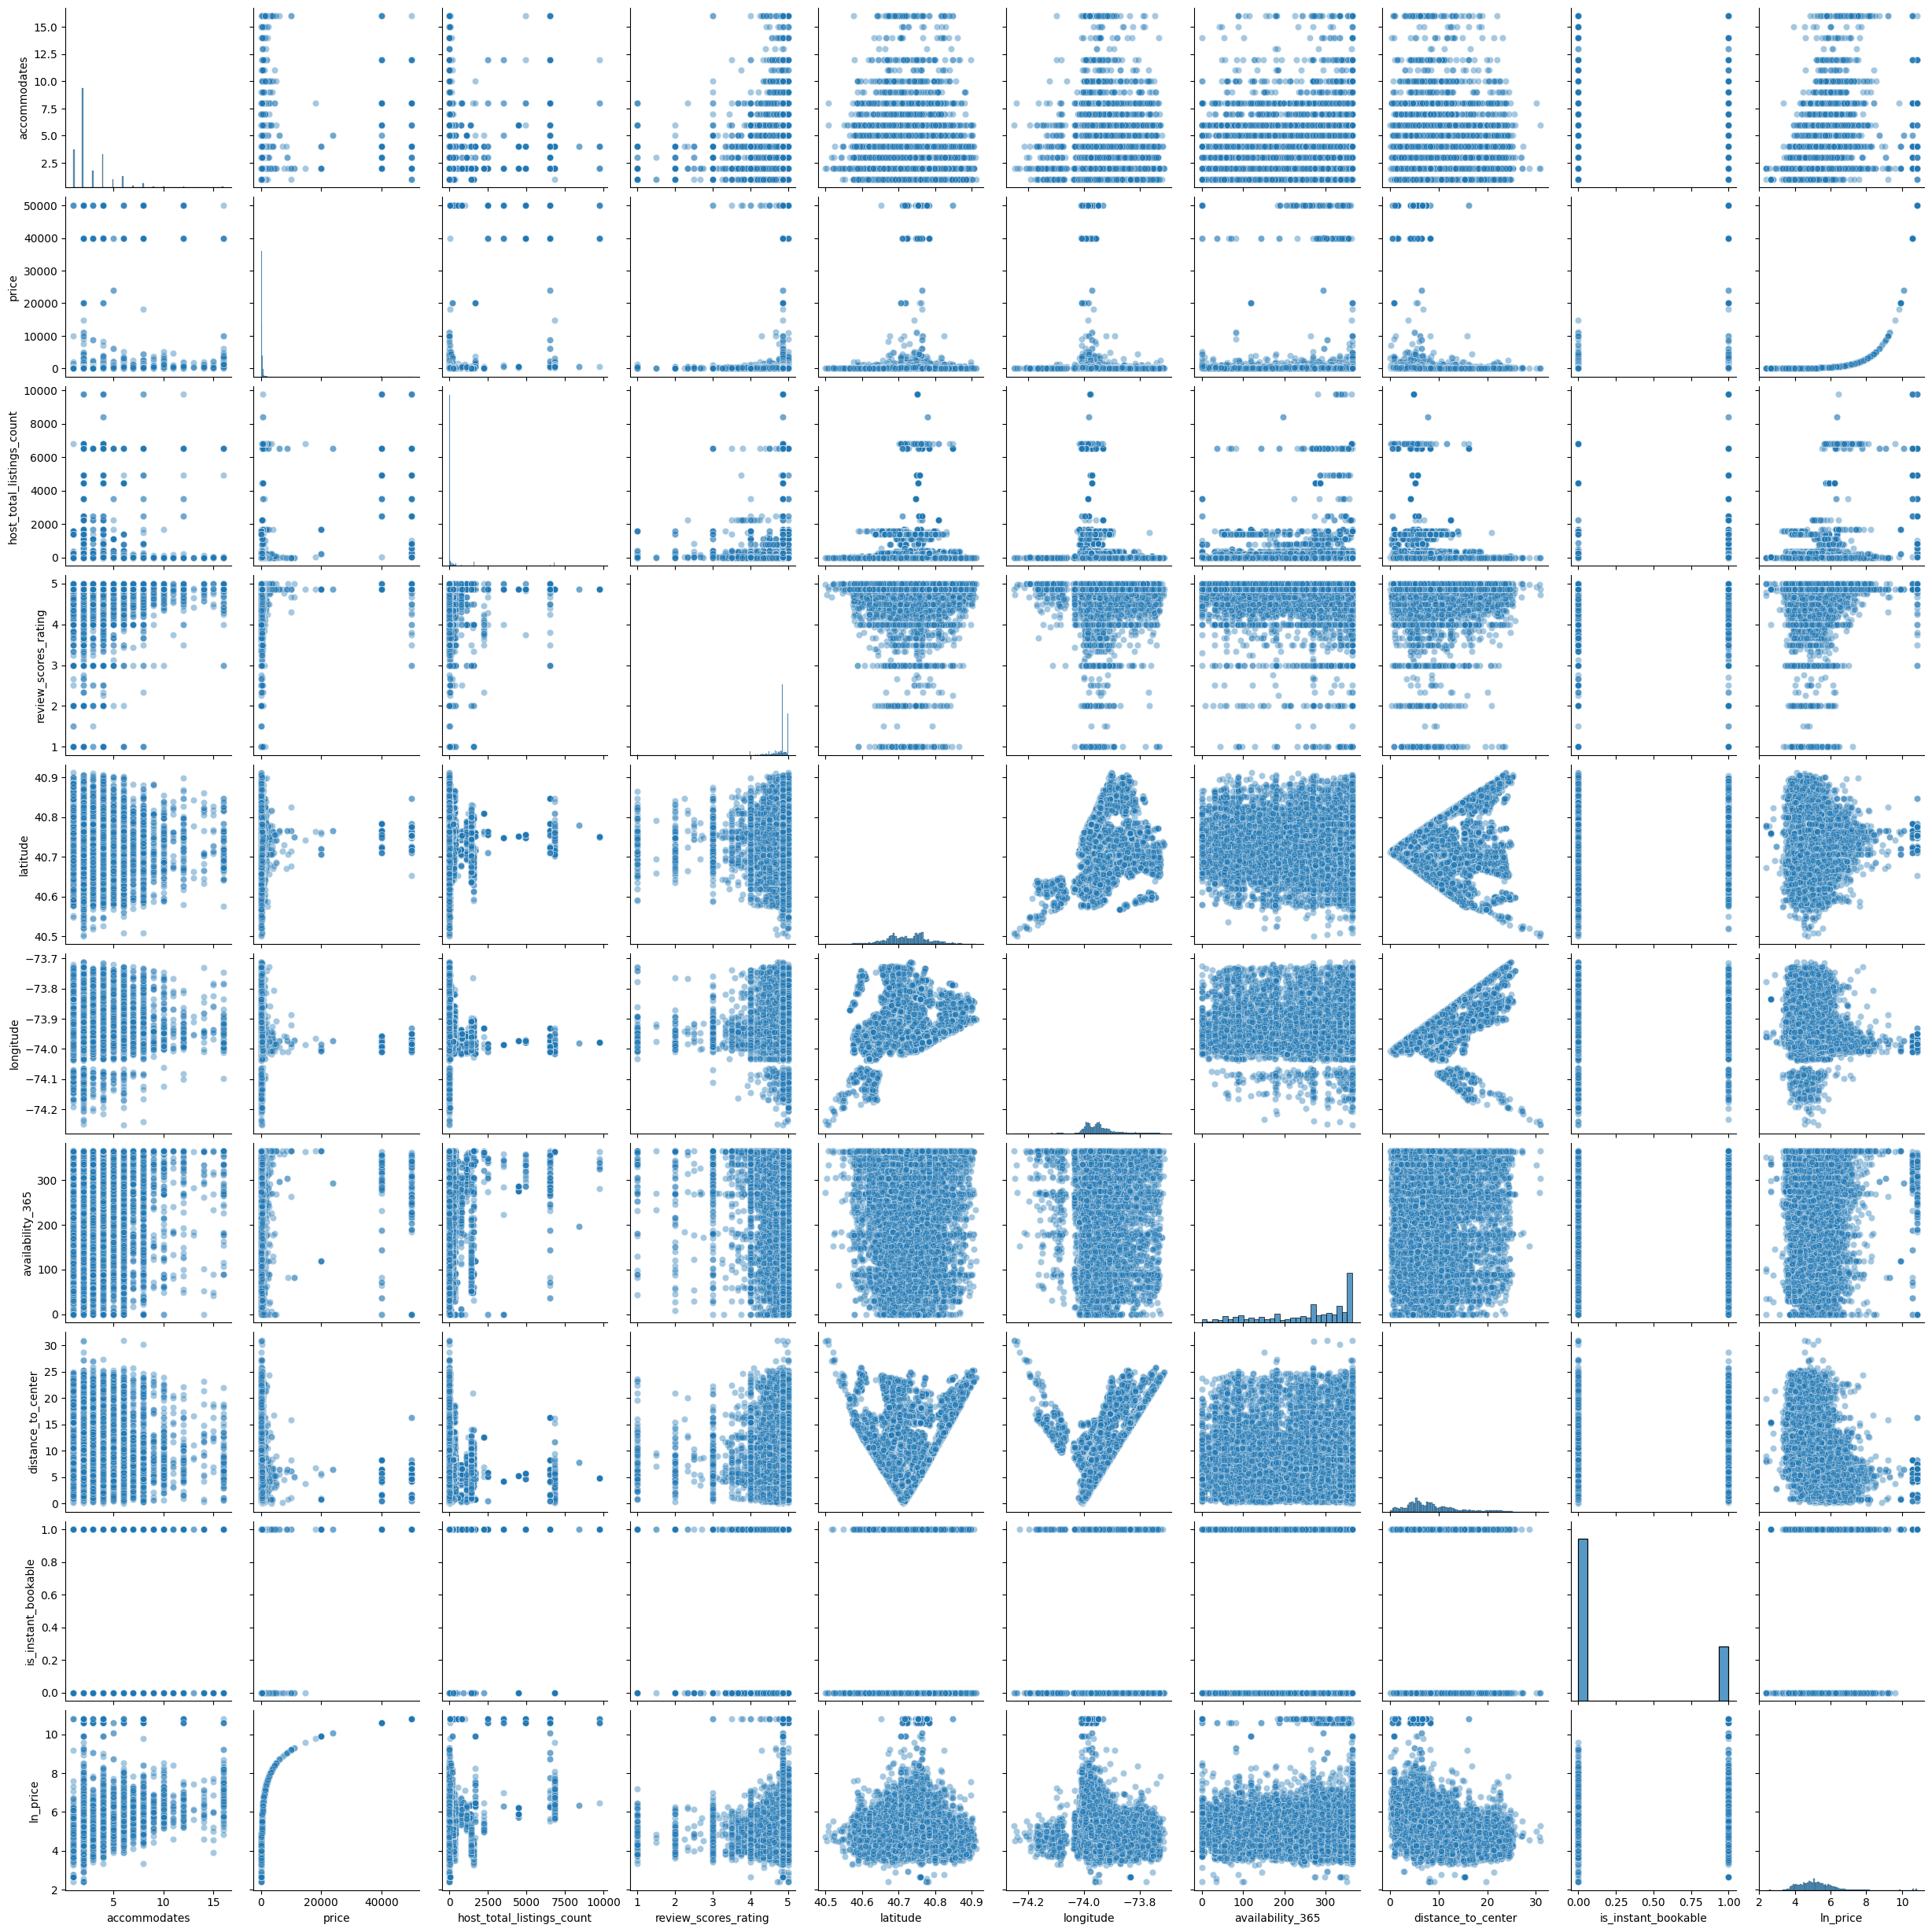

In [82]:
sns.pairplot(df1, kind='scatter', plot_kws={'alpha':0.4})

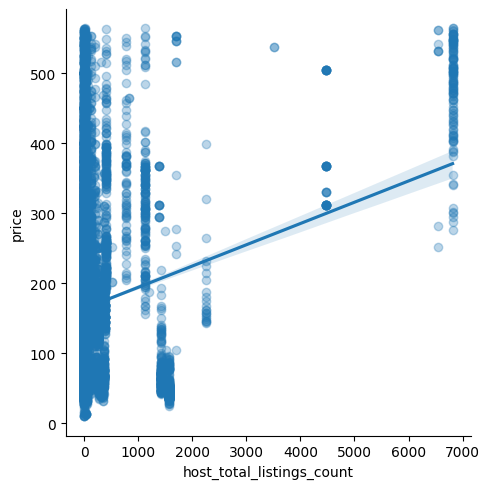

In [171]:
sns.lmplot(x = 'host_total_listings_count', 
           y = 'price',
           data = df,
           scatter_kws={'alpha':0.3}) 

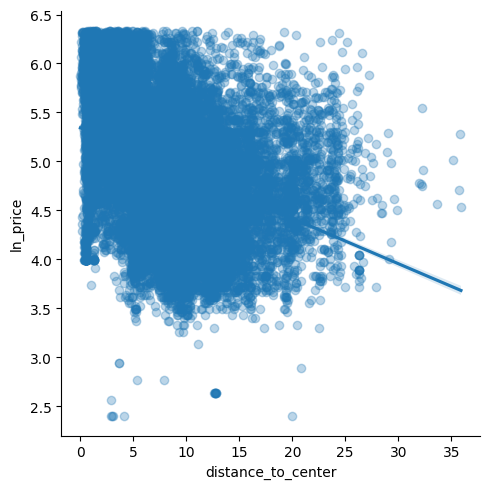

In [172]:
sns.lmplot(x = 'distance_to_center', 
           y = 'ln_price',
           data = df, 
           scatter_kws={'alpha':0.3}) 

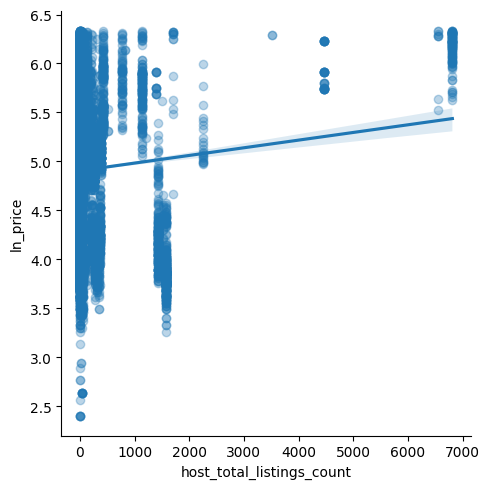

In [173]:
sns.lmplot(x = 'host_total_listings_count', 
           y = 'ln_price',
           data = df, 
           scatter_kws={'alpha':0.3}) 

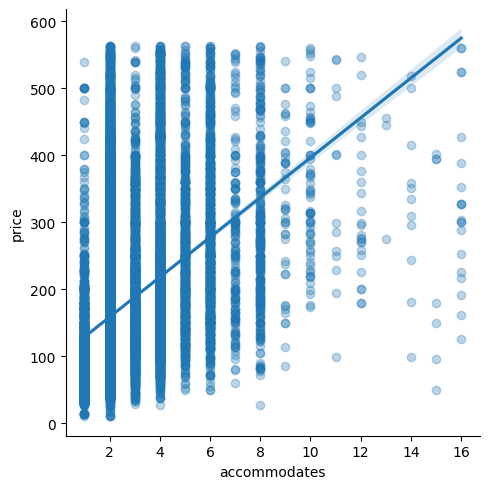

In [175]:
sns.lmplot(x = 'accommodates', 
           y = 'price',
           data = df, 
           scatter_kws={'alpha':0.3}) 

In [178]:
df_clean = df.dropna()

# MODEL

### Setup

In [179]:
from sklearn.model_selection import train_test_split

### Variablen X und Zielvariable y

In [180]:
df_clean.columns

Index(['id', 'neighbourhood_group_cleansed', 'room_type', 'instant_bookable',
       'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'host_total_listings_count', 'distance_to_center', 'price', 'ln_price'],
      dtype='object')

In [181]:
X = df_clean[['distance_to_center', 'host_total_listings_count', 'accommodates']]
y = df_clean['ln_price']

### Train-test-split

In [182]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [183]:
df_clean.shape

(18775, 12)

In [184]:
y_train

6573     5.484797
3672     4.248495
2205     5.707110
8747     4.488636
1582     6.198479
           ...   
11673    4.394449
12379    3.806662
5536     6.030685
863      4.574711
16449    4.976734
Name: ln_price, Length: 13142, dtype: float64

### Training the model

In [185]:
from sklearn.linear_model import LinearRegression

In [186]:
lm = LinearRegression()

In [187]:
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Koeffizienten

In [188]:
lm.coef_

array([-3.97310033e-02,  6.53414812e-05,  1.89544954e-01])

In [189]:
cdf = pd.DataFrame(lm.coef_, X.columns, columns=['Coef'])
print(cdf)

                               Coef
distance_to_center        -0.039731
host_total_listings_count  0.000065
accommodates               0.189545


### Predictions

In [190]:
predictions = lm.predict(X_test)

In [191]:
predictions

array([4.55825761, 5.68270329, 6.20994686, ..., 5.46536149, 5.21059976,
       5.44668322], shape=(5633,))

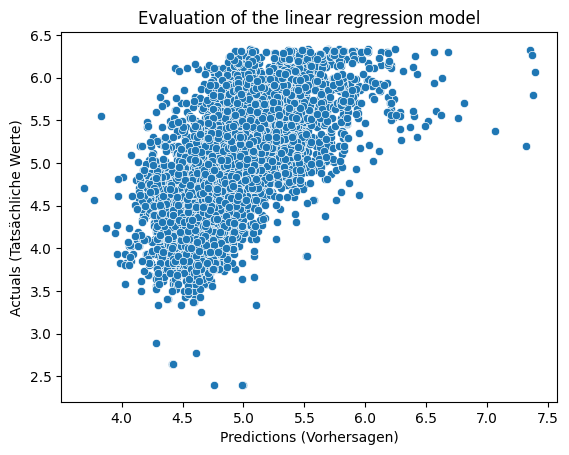

In [192]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel("Predictions (Vorhersagen)")
plt.ylabel("Actuals (Tatsächliche Werte)")
plt.title("Evaluation of the linear regression model")
plt.show()

In [193]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [194]:
print("Mean Absolute Error: ", mean_absolute_error(y_test, predictions))
print("Mean Squared Error: ", mean_squared_error(y_test, predictions))
print("RMSE: ", math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error:  0.41995209026018593
Mean Squared Error:  0.27048257721950764
RMSE:  0.5200793951114653


<Axes: ylabel='ln_price'>

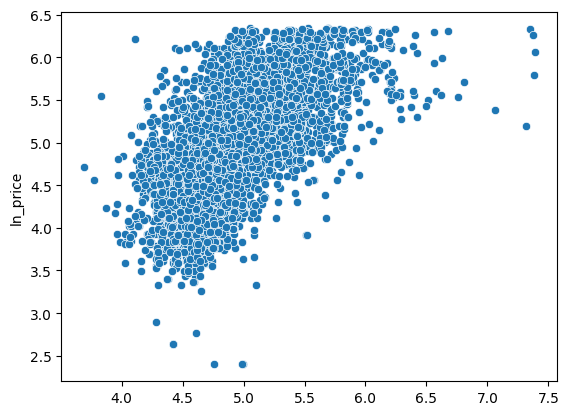

In [195]:
sns.scatterplot(x=predictions, y=y_test)

### Residuals

In [196]:
residuals = y_test - predictions
residuals

12054    0.056863
13690   -0.177372
1865    -0.061479
2707     0.329203
19170    0.327538
           ...   
19297    1.226449
13528    0.090692
5924    -0.552707
8096    -0.374318
15380    0.405519
Name: ln_price, Length: 5633, dtype: float64

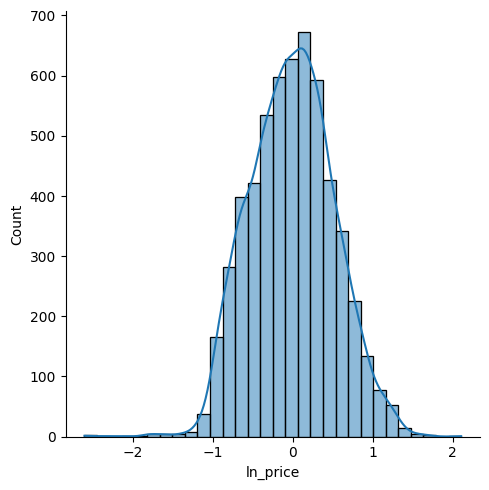

In [197]:
sns.displot(residuals, bins=30, kde=True)

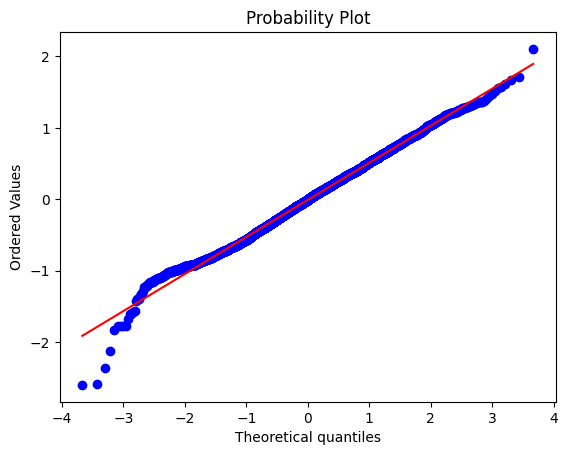

In [202]:
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()

In [204]:
import numpy as np
from sklearn.metrics import r2_score

# Annahmen: 
# X_test, y_test sind die Testdaten
# model ist das trainierte Regressionsmodell

# 1. Berechne den R²
y_pred = lm.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R²-Wert: {r2:.4f}")

# 2. Berechne den Adjusted R²
n = X_test.shape[0]  # Stichprobengröße (Anzahl der Testdatenpunkte)
k = X_test.shape[1]  # Anzahl der Features (Spalten)

# Adjusted R² Formel: 1 - (1 - R²) * (n - 1) / (n - k - 1)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
print(f"Adjusted R²-Wert: {adj_r2:.4f}")

R²-Wert: 0.3917
Adjusted R²-Wert: 0.3914
